In [44]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.11.0+cu128


In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [46]:

DATA_DIR = Path("../data/processed/chest_xray")

TRAIN_DIR = DATA_DIR / "new_train"
VAL_DIR = DATA_DIR / "new_val"

print(TRAIN_DIR)
print(VAL_DIR)

..\data\processed\chest_xray\new_train
..\data\processed\chest_xray\new_val


In [47]:
print(TRAIN_DIR.exists())
print(VAL_DIR.exists())

True
True


### Image Transformations

In [48]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Create Datasets

In [49]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transforms
)

print("Classes:", train_dataset.classes)
print("Number of Classes:", len(train_dataset.classes))

Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Number of Classes: 3


### DataLoaders

In [50]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # Windows safer
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train Batches:", len(train_loader))
print("Validation Batches:", len(val_loader))

Train Batches: 147
Validation Batches: 17


## Verify Batch Shapes

In [51]:
images, labels = next(iter(train_loader))

print("Image Shape :", images.shape)
print("Label Shape :", labels.shape)

Image Shape : torch.Size([32, 3, 224, 224])
Label Shape : torch.Size([32])


### Baseline CNN


In [52]:
class PneumoniaCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128,3)
        )

    def forward(self,x):

        x = self.features(x)
        x = self.classifier(x)

        return x

### Create Model

In [53]:
model = PneumoniaCNN().to(device)

print(model)
print(
    f"Trainable Parameters: "
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

### Class Weights (Important for Recall)

In [54]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

targets = train_dataset.targets

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(targets),
    y=targets
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

print(class_weights)

tensor([0.6870, 1.2971, 1.2928], device='cuda:0')


### Loss & Optimizer

In [55]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)
print("Scheduler Initialized")


Scheduler Initialized


### History Dictionary

In [56]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_recall": [],
    "val_f1": []
}

### Model Save Path

In [ ]:
# Model Saving
'''
from pathlib import Path

MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "baseline_cnn_best.pth"

'''

### Early Stopping Variables

In [58]:
# Early Stopping

best_recall = 0.0

patience = 5

counter = 0

### Training Function

In [59]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

### Validation Function

In [60]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(loader)

    accuracy = accuracy_score(all_labels, all_preds)

    # average="macro": dataset has 3 classes (BACTERIAL_PNEUMONIA, NORMAL,
    # VIRAL_PNEUMONIA), so "binary" is invalid here and will raise a ValueError.
    # Macro-averaging treats each class equally, which matters since you're
    # using class weights to combat imbalance in the first place.
    
    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return val_loss, accuracy, precision, recall, f1

### Training Loop

In [ ]:
''' 

EPOCHS = 30

# Reset history/early-stopping state here so re-running this cell starts clean
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_recall = 0.0
counter = 0

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, accuracy, precision, recall, f1 = validate(
        model,
        val_loader,
        criterion
    )

    # Step the LR scheduler on validation loss (this was never called before)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(accuracy)
    history["val_precision"].append(precision)
    history["val_recall"].append(recall)
    history["val_f1"].append(f1)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Acc: {accuracy:.4f} "
        f"Precision: {precision:.4f} "
        f"Recall: {recall:.4f} "
        f"F1: {f1:.4f}"
    )

    # Early stopping + checkpointing, keyed on macro recall
    if recall > best_recall:

        best_recall = recall
        counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(f"✅ Best Model Saved (recall: {best_recall:.4f})")

    else:
        counter += 1
        print(f"No improvement. Early stop counter: {counter}/{patience}")

        if counter >= patience:
            print(f"⏹️ Early stopping triggered at epoch {epoch+1}")
            break
            
'''

Epoch [1/30] Train Loss: 0.8167 Val Loss: 0.7581 Acc: 0.6386 Precision: 0.6399 Recall: 0.6623 F1: 0.6448
✅ Best Model Saved (recall: 0.6623)
Epoch [2/30] Train Loss: 0.7262 Val Loss: 0.8501 Acc: 0.6348 Precision: 0.6140 Recall: 0.6217 F1: 0.5744
No improvement. Early stop counter: 1/5
Epoch [3/30] Train Loss: 0.7075 Val Loss: 0.6619 Acc: 0.7094 Precision: 0.6958 Recall: 0.7030 F1: 0.6983
✅ Best Model Saved (recall: 0.7030)
Epoch [4/30] Train Loss: 0.6567 Val Loss: 0.7120 Acc: 0.6367 Precision: 0.6727 Recall: 0.6967 F1: 0.6540
No improvement. Early stop counter: 1/5
Epoch [5/30] Train Loss: 0.6316 Val Loss: 0.6199 Acc: 0.7533 Precision: 0.7655 Recall: 0.7529 F1: 0.7577
✅ Best Model Saved (recall: 0.7529)
Epoch [6/30] Train Loss: 0.6114 Val Loss: 0.7375 Acc: 0.6788 Precision: 0.7331 Recall: 0.6773 F1: 0.6873
No improvement. Early stop counter: 1/5
Epoch [7/30] Train Loss: 0.5911 Val Loss: 0.5757 Acc: 0.7591 Precision: 0.7535 Recall: 0.7350 F1: 0.7355
No improvement. Early stop counter: 2

In [64]:
model.load_state_dict(
    torch.load(
        "../models/baseline_cnn_best.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [65]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Predictions generated!")

Predictions generated!


In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[191   4  58]
 [ 14 116   5]
 [ 47   1  87]]


In [68]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes
    )
)

                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.76      0.75      0.76       253
             NORMAL       0.96      0.86      0.91       135
    VIRAL_PNEUMONIA       0.58      0.64      0.61       135

           accuracy                           0.75       523
          macro avg       0.77      0.75      0.76       523
       weighted avg       0.76      0.75      0.76       523



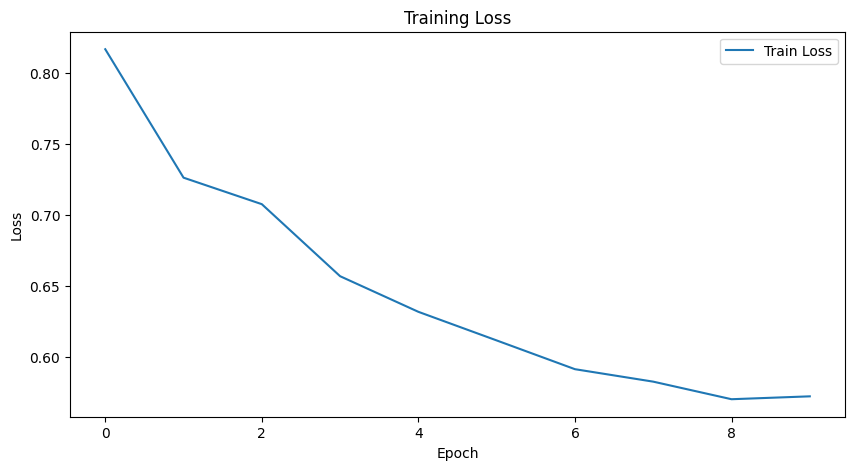

In [69]:
plt.figure(figsize=(10,5))

plt.plot(history["train_loss"], label="Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()

In [71]:
print(history)

{'train_loss': [0.8167492471584658, 0.7261640770094735, 0.7074773226465497, 0.656676858663559, 0.6315614005335334, 0.6113897716107012, 0.5911085200147564, 0.5823226133171393, 0.5699299036645565, 0.5719654900687081], 'val_loss': [0.7580594245125266, 0.8501189217409667, 0.6619317110847024, 0.7119900847182554, 0.6199218052275041, 0.7375473853419808, 0.5756599188727491, 0.7623039231745198, 0.8295086096314823, 0.9709630613763105], 'val_acc': [0.638623326959847, 0.6347992351816444, 0.7093690248565966, 0.6367112810707457, 0.7533460803059273, 0.6787762906309751, 0.7590822179732314, 0.6768642447418738, 0.6042065009560229, 0.6367112810707457], 'val_precision': [0.6399190079511189, 0.6140042506908759, 0.6958173894557823, 0.6726605993125817, 0.7655380646289737, 0.7331151870030713, 0.7535451108547995, 0.658553560540419, 0.6983839180134016, 0.6463503132562671], 'val_recall': [0.6623139608646854, 0.6216756941394622, 0.7030010247401551, 0.696696432928317, 0.7528814717220514, 0.6773142048504367, 0.7349

In [73]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df.to_csv(
    "../artifacts/cnn_training_history.csv",
    index=False
)

print("Training history saved!")

Training history saved!


In [77]:
print("="*50)
print("BASELINE CNN RESULTS")
print("="*50)

print(f"Best Recall : {best_recall:.4f}")
print(f"Best Accuracy : {max(history['val_acc']):.4f}")
print(f"Best F1 : {max(history['val_f1']):.4f}")

print("="*50)

BASELINE CNN RESULTS
Best Recall : 0.7529
Best Accuracy : 0.7591
Best F1 : 0.7577


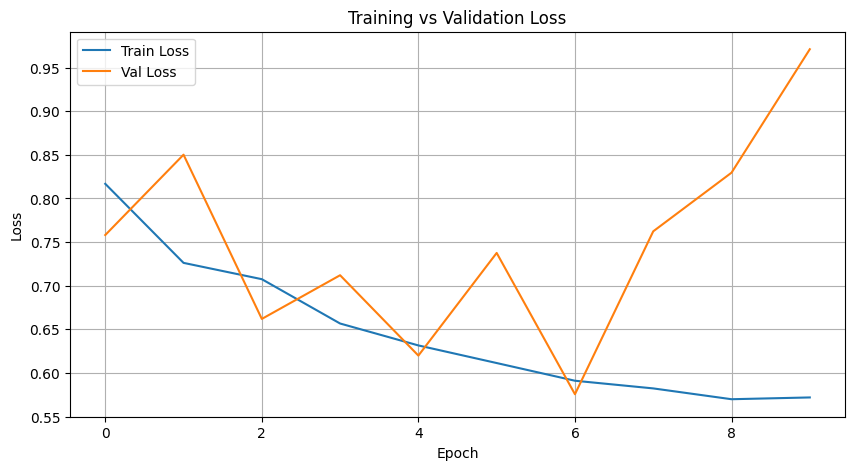

In [78]:
plt.figure(figsize=(10,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    "../artifacts/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

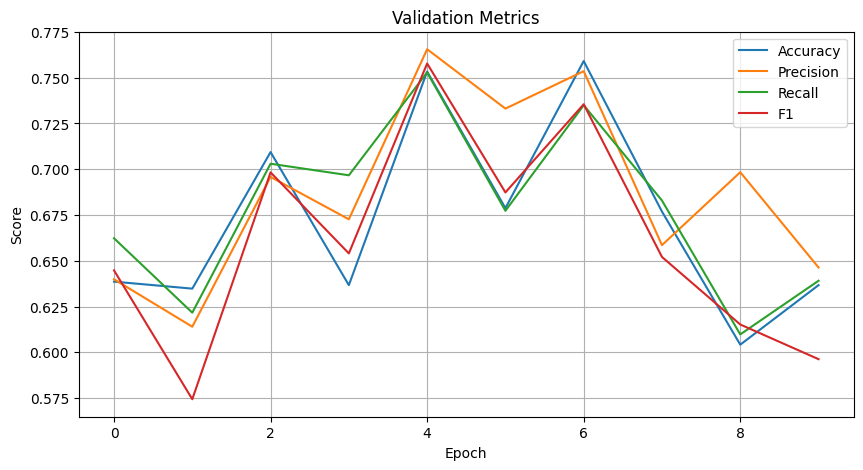

In [79]:
plt.figure(figsize=(10,5))

plt.plot(history["val_acc"], label="Accuracy")
plt.plot(history["val_precision"], label="Precision")
plt.plot(history["val_recall"], label="Recall")
plt.plot(history["val_f1"], label="F1")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")

plt.legend()
plt.grid(True)

plt.savefig(
    "../artifacts/metrics_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

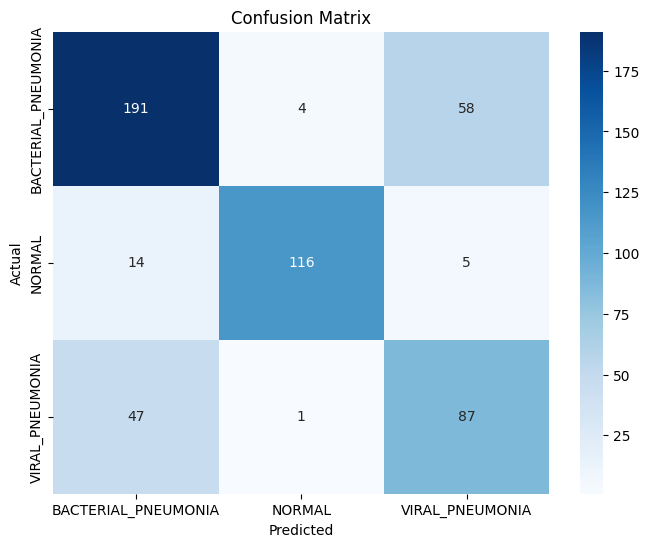

In [80]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(
    "../artifacts/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
)

with open(
    "../artifacts/classification_report.txt",
    "w"
) as f:
    f.write(report)

print(report)

                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.76      0.75      0.76       253
             NORMAL       0.96      0.86      0.91       135
    VIRAL_PNEUMONIA       0.58      0.64      0.61       135

           accuracy                           0.75       523
          macro avg       0.77      0.75      0.76       523
       weighted avg       0.76      0.75      0.76       523

